# Модель оценки стоимости автомобилей
---

## Описание 

###  Общая информация

- заказчик: **AutoValue AI** - стартап, который внедряет модель мгновенного выкупа автомобилей на рынке подержанных автомобилей
- Как должнн работать сервис:
    - Клиент заполняет анкету в приложении.
    - Алгоритм за одну секунду рассчитывает стоимость.
    - Если клиента устраивает цена, он приезжает в ближайший офис продаж, где техник за 15 минут подтверждает состояние авто, а клиент мгновенно получает деньги на счёт.
- доступные данные -- информация о 10 000 прошлых сделок, которые эксперты провели вручную

## Бизнес-задача
Разработать автоматизированную систему оценки стоимости автомобилей, основанную на накопленном специалистами опыте. 
Внедрение модели позволит: 
- увеличить скорость оценки -- это позволит удержать больше клиентов
- повысить качество оценки -- это снизит риск убытков
- повысит пропускную способность сервиса (обслуживание большего количества клиентов в единицу времени) -- это способствует масштабированию бизнеса  

## Цель
- разработать модель машинного обучения для оценки автомобилей, учитывающую нелинейные связи между признаками

## Задачи
- определить наиболее эффективную библиотеку градиентного бустинга: LightGBM, CatBoost, XGBoost 
- минимизировать финансовые риски
- обеспечить прозрачность работы модели

## ML задача

Вид задачи:
- обучение с учителем
- подтип: регрессия 

Целевая переменная:
- **price_rub** -- рыночная стоимость автомобиля в рублях (для бизнеса это реальная сумма сделки, которую нужно предсказать).

Особенности:
- нелинейные свзяи между признаками
- отдельные датасеты под train и test

## Бизнес метрики
1. **Доля опасных переплат (Overpricing Rate)** - это процент случаев, когда модель предсказала цену на 20% выше реальной. Каждая такая машина — это прямой убыток. Покупая машину слишком дорого, компания не сможет перепродать с прибылью.

    Логика расчёта:

    - $Error Ratio = \frac{Предсказание−Реальность}{Реальность}$ 
    - если зачение > 0.2 - помечаем этот случай как «опасный».
    - Делим количество таких «опасных» случаев на общее количество машин в выборке

2. **Упущенная выгода (Underpricing Loss)** -  суммарная разница в случаях, когда модель занизила цену более чем на 20%. В таких случаях клиент просто развернётся и уйдёт к конкурентам. Компания теряет долю рынка.

    Логика расчета:
    - Находим все случаи, где наше предложение было ниже реальности более чем на 20% ($Error Ratio < -0.20$)
    - Для этих случаев вычисляем разницу между реальной ценой и нашим прогнозом. Это и есть сумма, которую недоплатили.
    - Суммируем все эти разницы

---
## 1. Настройка проекта и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import optuna
import shap

In [2]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [3]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

In [4]:
# пути для скачивания данных
data_path_train = 'https://code.s3.yandex.net/datasets/ds_s16_train_data.csv'
data_path_test = 'https://code.s3.yandex.net/datasets/ds_s16_test_data.csv'

In [5]:
df_train = pd.read_csv(data_path_train)
display(df_train.info(), df_train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   object 
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   object 
 6   transmission        8000 non-null   object 
 7   color               8000 non-null   object 
 8   service_history     8000 non-null   object 
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   object 
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 812.6+ KB


None

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


In [6]:
df_test = pd.read_csv(data_path_test)
display(df_test.info(), df_test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   object 
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   object 
 6   transmission        2000 non-null   object 
 7   color               2000 non-null   object 
 8   service_history     2000 non-null   object 
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   object 
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.2+ KB


None

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


Итог:
- данные для train и test считаны корректно
- явных пропусков нет
- типы данных соответсвуют описанию

---
## 2. EDA (Экспресс-анализ данных)
Бизнесу важно понимать природу данных.
- Изучите распределение целевой переменной price_rub.
- Проверьте корреляции.

### Общая информация

In [7]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [8]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [9]:
get_base_df_info(name='Train dataset', df=df_train)

Общая информация о датафрейме Train dataset


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


,Метрика,Значение
0,Строк,8000.0
1,Колонок,13.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,7.0
4,Числовых колонок,6.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
price_rub,int64,0,0.0,7929
mileage_kmpl,float64,0,0.0,2108
make_year,int64,0,0.0,29
engine_cc,int64,0,0.0,10
brand,object,0,0.0,10
color,object,0,0.0,6
accidents_reported,int64,0,0.0,6
region,object,0,0.0,6
owner_count,int64,0,0.0,5
fuel_type,object,0,0.0,3


Типы колонок


,Категориальные колонки,Числовые колонки
0,fuel_type,make_year
1,brand,mileage_kmpl
2,transmission,engine_cc
3,color,owner_count
4,service_history,accidents_reported
5,insurance_valid,price_rub
6,region,NaN


--------------------------------------------------


Анализ:
- явных дублей и пропусков нет
- 7 категориальных и 5 числовых признаков + таргет числовой

### Анализ распределений 

In [10]:
cat_cols, num_cols = get_cat_num_cols(df=df_train)

In [11]:
target_col = 'price_rub'
cat_cols_feat = cat_cols.copy()
num_cols_feat = [col for col in num_cols if col != target_col]

In [12]:
def plot_hist_box(
    df: pd.DataFrame, 
    feature_name: str,
    x_label: str = 'значение',
    bins=30
):
    """Гистограмма + ящик с усами для анализа распределений количественных данных"""
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0], bins=bins)
    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1])
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    plt.show()

#### Таргет

In [13]:
df_train[target_col].describe()

count    8.000000e+03
mean     6.836479e+05
std      2.649235e+05
min      9.500000e+04
25%      4.938570e+05
50%      6.638660e+05
75%      8.550560e+05
max      1.676525e+06
Name: price_rub, dtype: float64

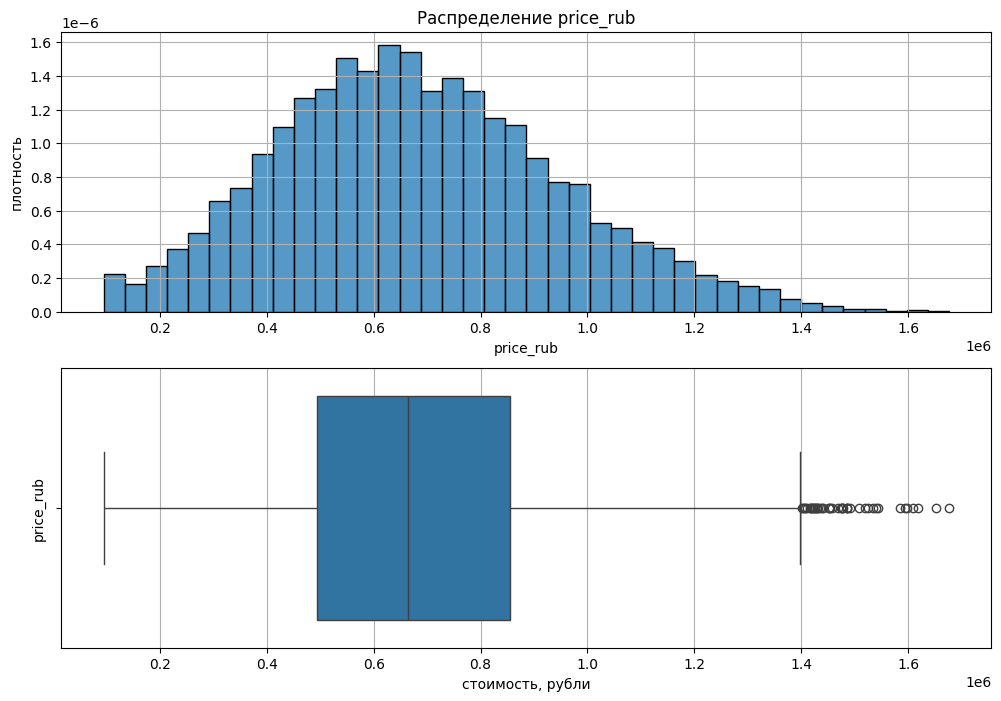

In [14]:
plot_hist_box(df=df_train, feature_name=target_col, x_label='стоимость, рубли', bins=40)

In [15]:
df_train[target_col].min()

np.int64(95000)

Анализ:
- распределение таргета симметричное (можно приблизить усеченным слева нормальным распределением)
- в правом хвосте распределения есть малочисленные выбросы 
- на левой границе можно отметить пороговое значение 95000 (подозрительно ровная сумма!), ниже которого значений нет. Возможно, это фиксированная нижняя цена для всех покупаемых на перепродажу авто. 

#### Количественные признаки

In [16]:
df_train[num_cols_feat].describe()

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,2009.221250,17.946343,2289.687500,3.001125,0.487875
std,8.388703,5.015565,1289.812139,1.419199,0.693839
min,1995.000000,5.000000,800.000000,1.000000,0.000000
25%,2002.000000,14.530000,1200.000000,2.000000,0.000000
50%,2009.000000,17.970000,2000.000000,3.000000,0.000000
75%,2017.000000,21.350000,3000.000000,4.000000,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,5.000000


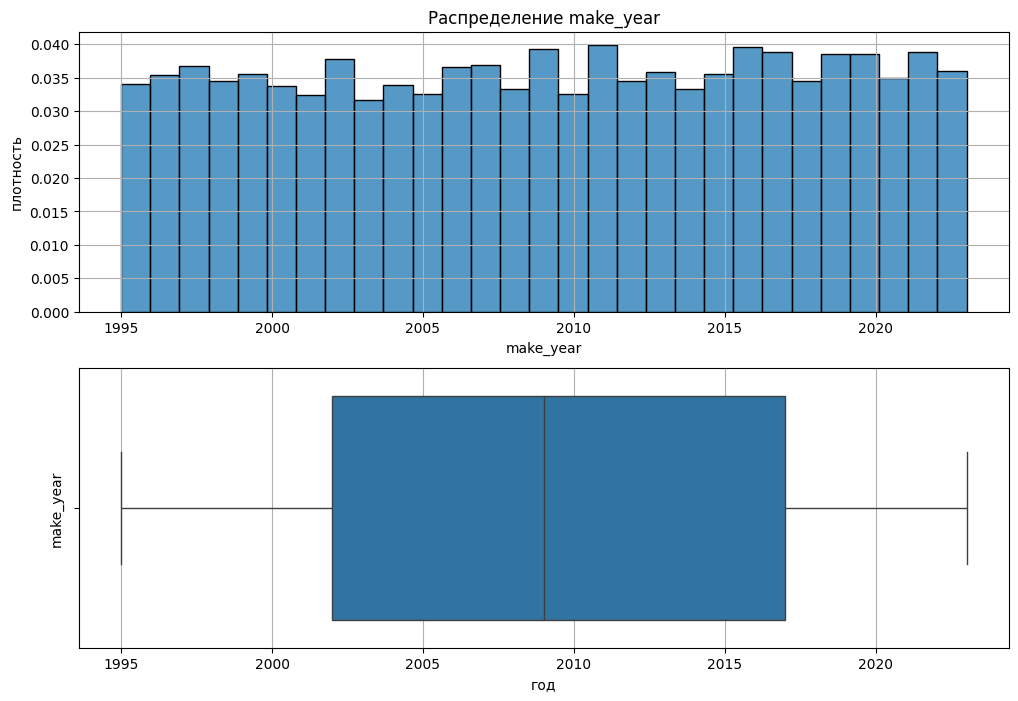

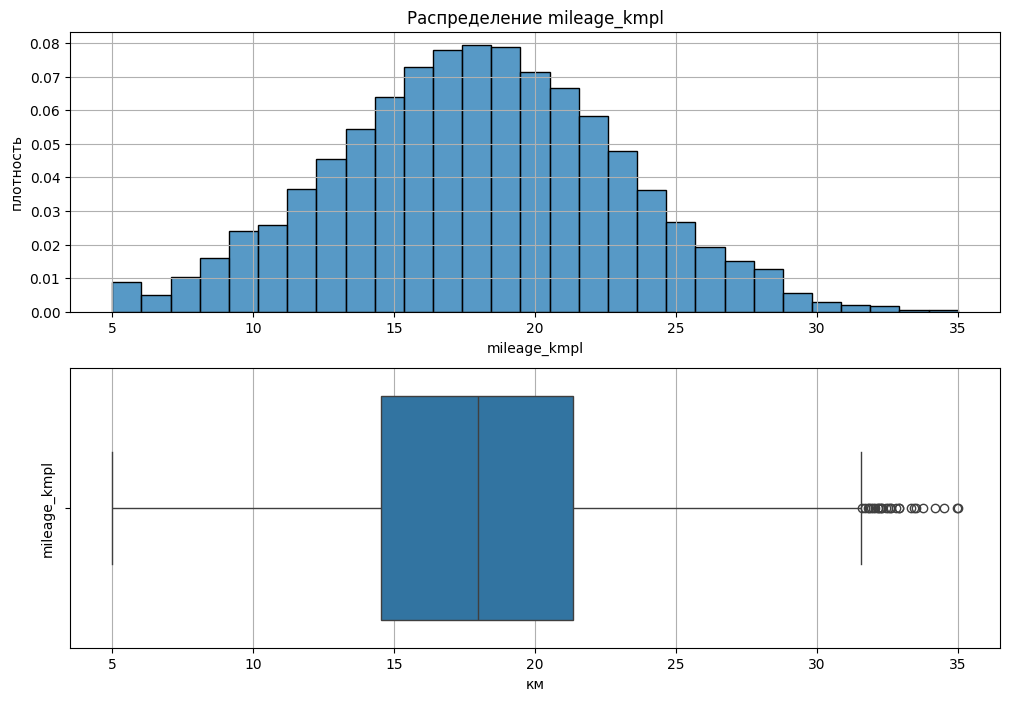

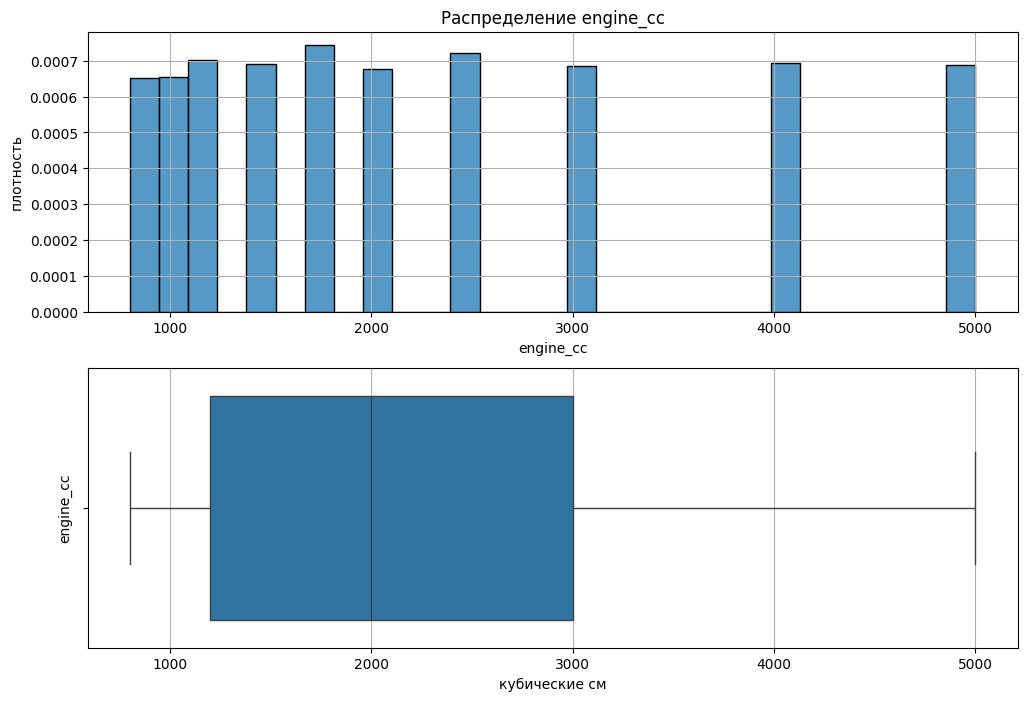

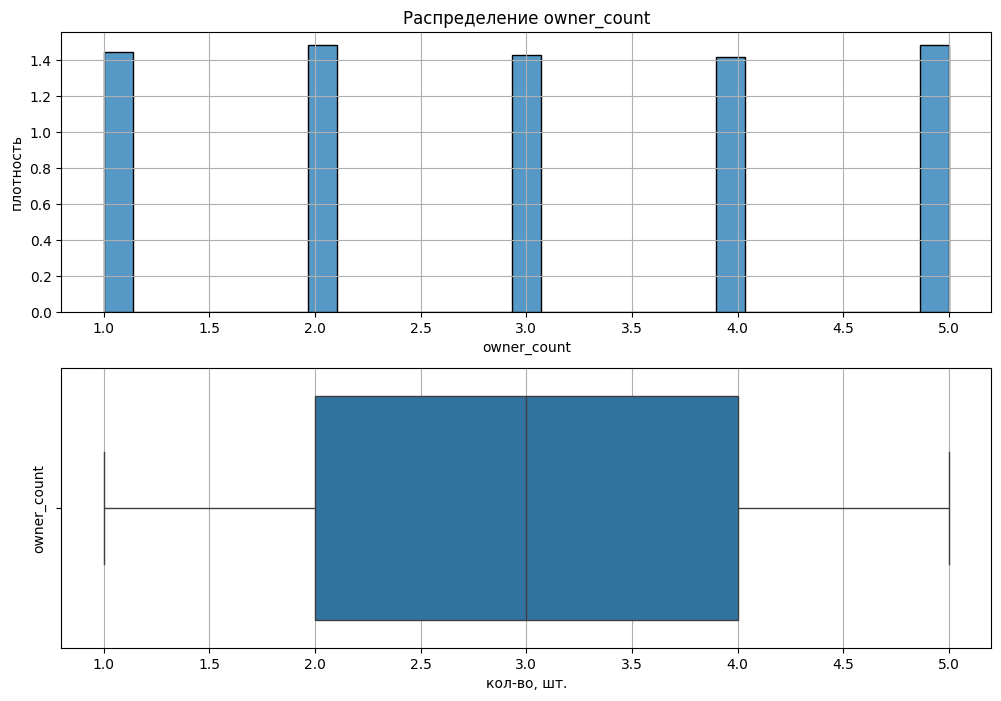

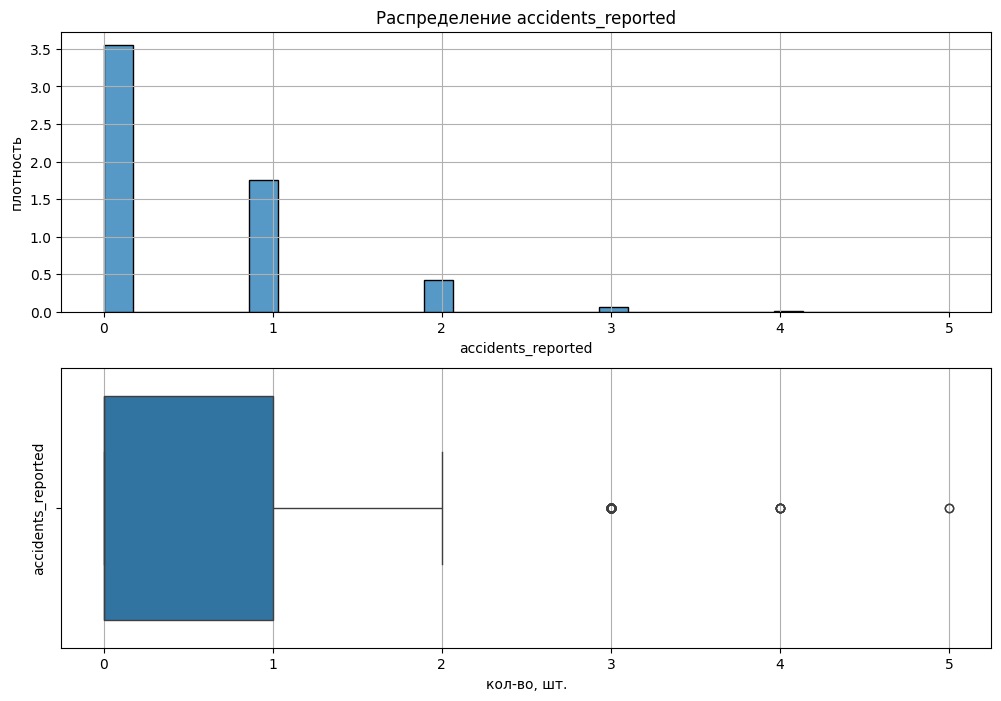

In [17]:
x_names = ['год', 'км', 'кубические см', 'кол-во, шт.', 'кол-во, шт.']
for col_name, x_name in zip(num_cols_feat, x_names):
    plot_hist_box(df=df_train, feature_name=col_name, x_label=x_name, bins=29)

Анализ:
- make_year	(Год выпуска) - распределение равномерное.
- mileage_kmpl	(кол-во литров на 1км) - симметричное распределение с явной минимальной границей в 5.0км. Есть малочисленные экстремальные значения на правом хвосте
- engine_cc	(Объём двигателя (в кубических см)) - дискретный набор стандартных по объему двигателя значений. Среди дискретных значений распределение равномерное. Чаще встречаются двигателя объемом до 2000 куб. см.
- owner_count	(Количество владельцев по ПТС) - от 1 до 5 целые значения. Распределение равномерное
- accidents_reported	(Количество зафиксированных ДТП) - от 0 до 5 целые значения. Распределение экспоненциально убывает. Чтобы усилить связь большого кол-ва ДТП с целевую переменной, стоит рассмотреть преобразование возведения в степень.

#### Категориальные данные 

In [18]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    counts = df[col_name].value_counts()
    freq_order = counts.index
    mean_value = counts.mean()

    ax = sns.countplot(data=df, x=col_name, order=freq_order)

    ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)

    # горизонтальная линия среднего значения
    plt.axhline(
        y=mean_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Среднее: {mean_value:.1f}",
    )

    plt.title(f"Распределение признака {col_name}")
    plt.ylabel("количество")
    plt.xticks(rotation=45)
    plt.legend()

    plt.ylim(top=plt.ylim()[1] * 1.05)

    plt.show()

In [19]:
df_train[cat_cols_feat].describe()

,fuel_type,brand,transmission,color,service_history,insurance_valid,region
count,8000,8000,8000,8000,8000,8000,8000
unique,3,10,2,6,3,2,6
top,Petrol,Nissan,Manual,White,Full,Yes,Юг
freq,3990,870,4812,1366,3985,6356,1408


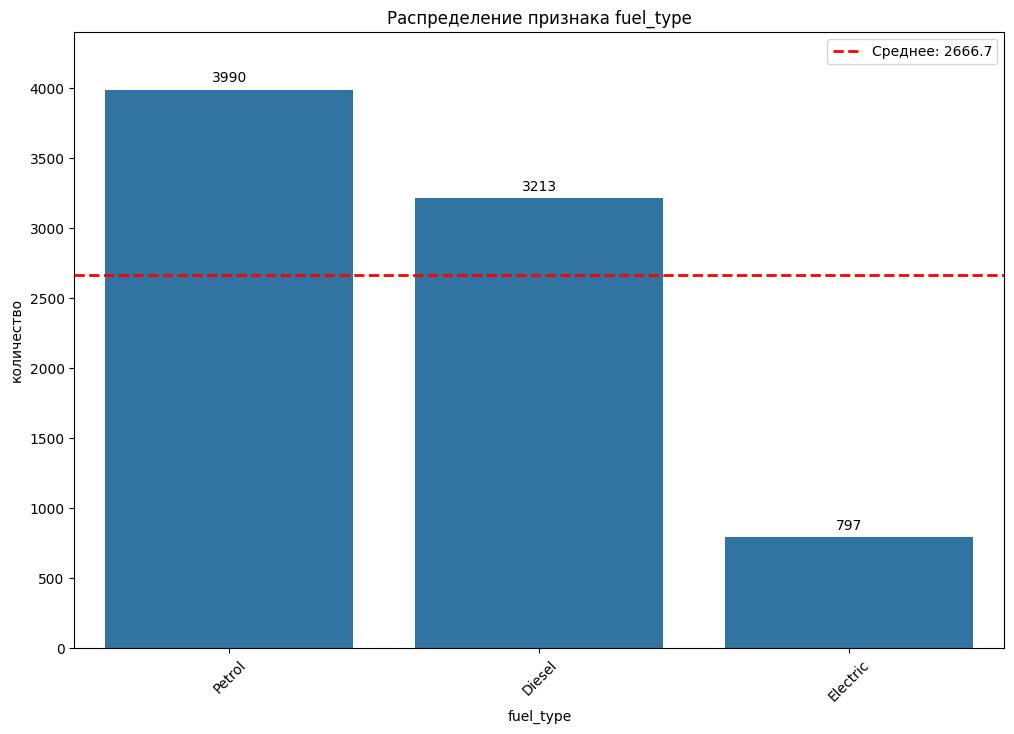

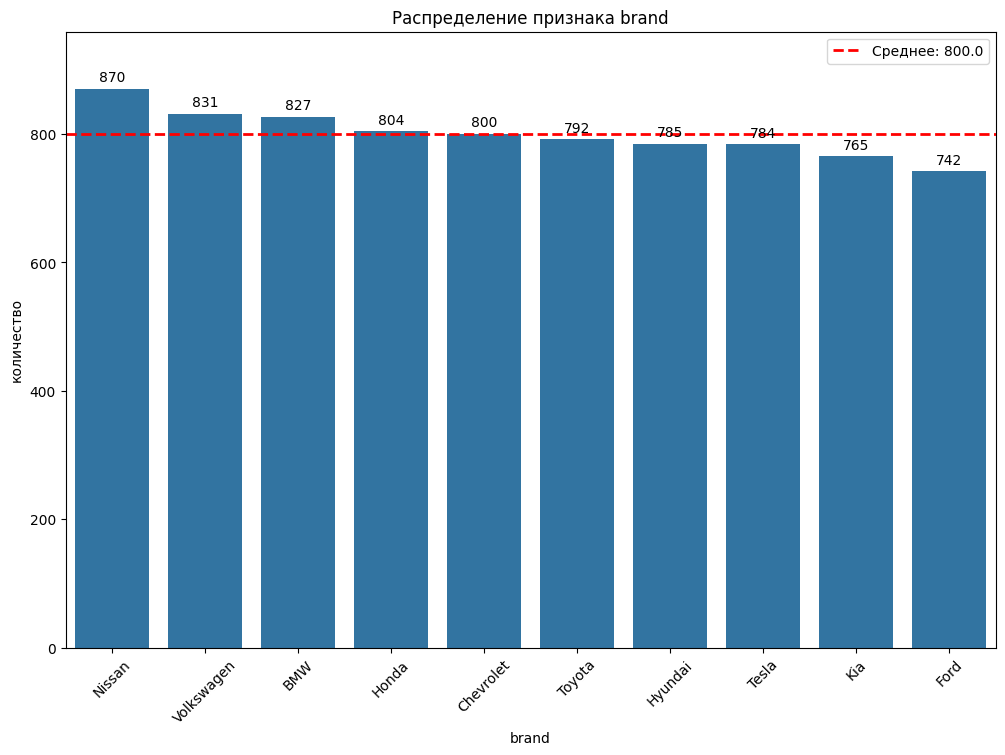

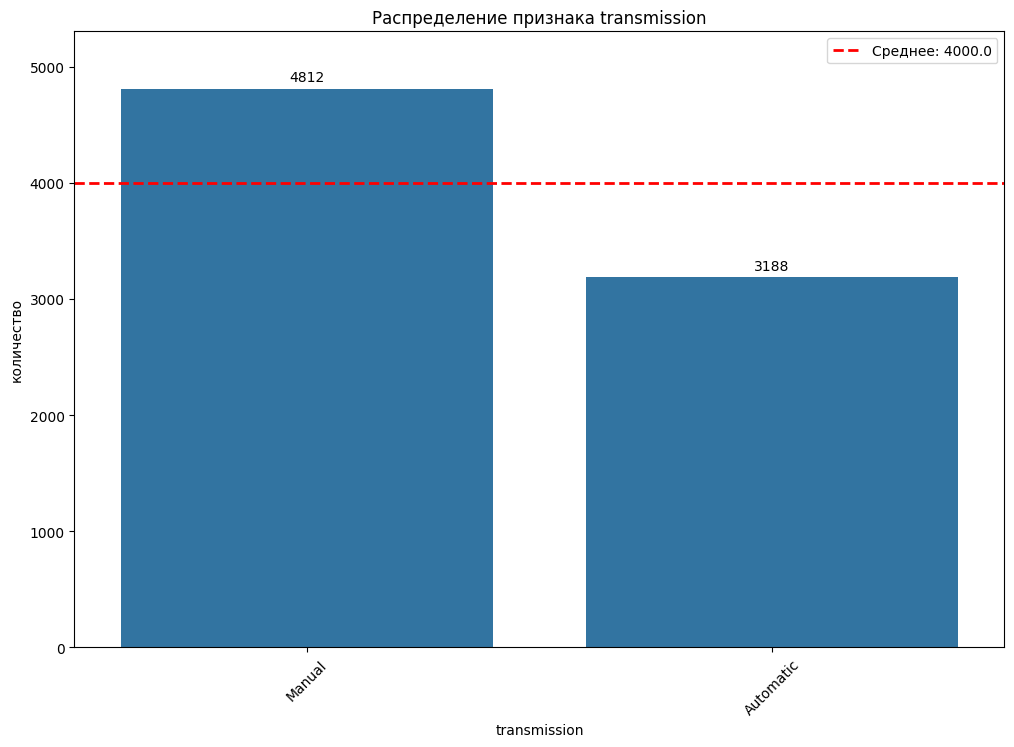

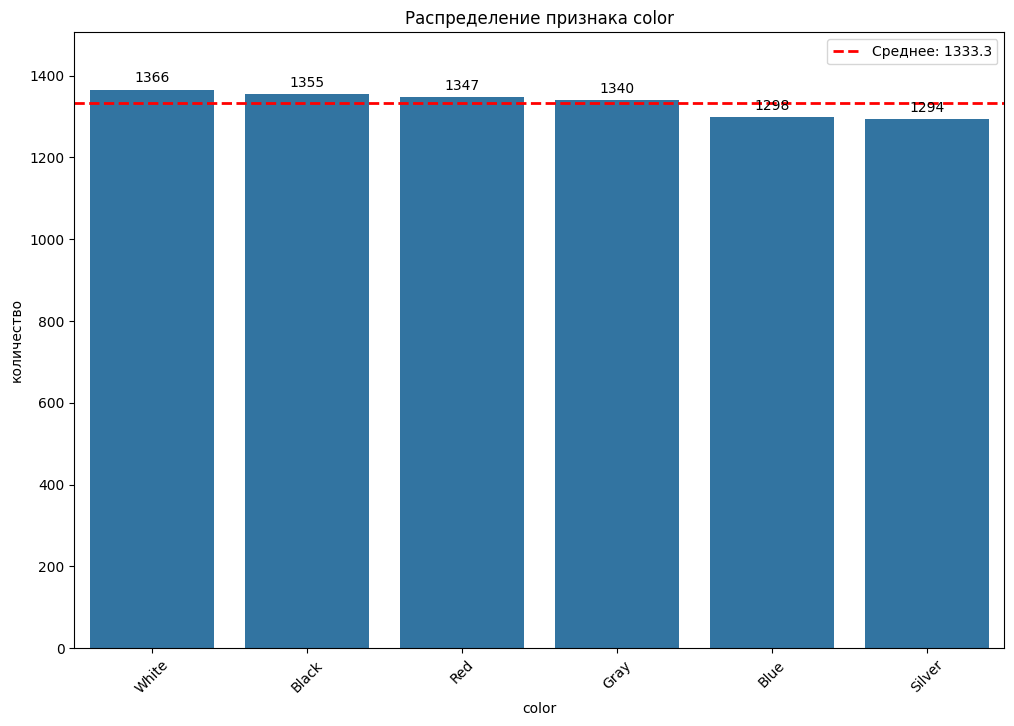

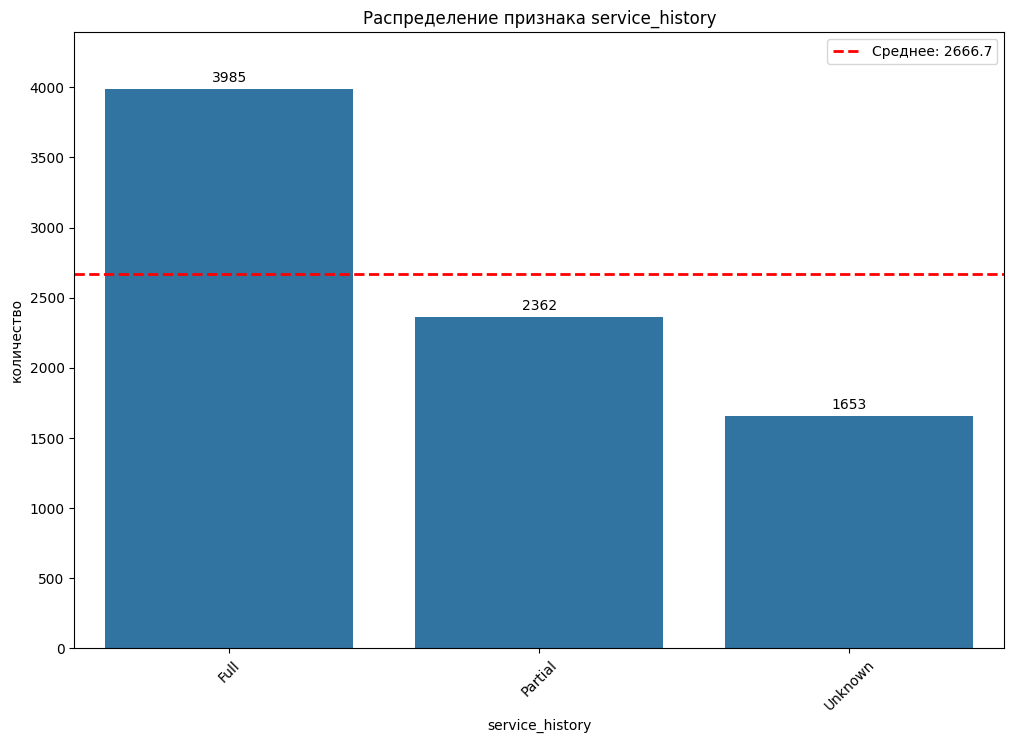

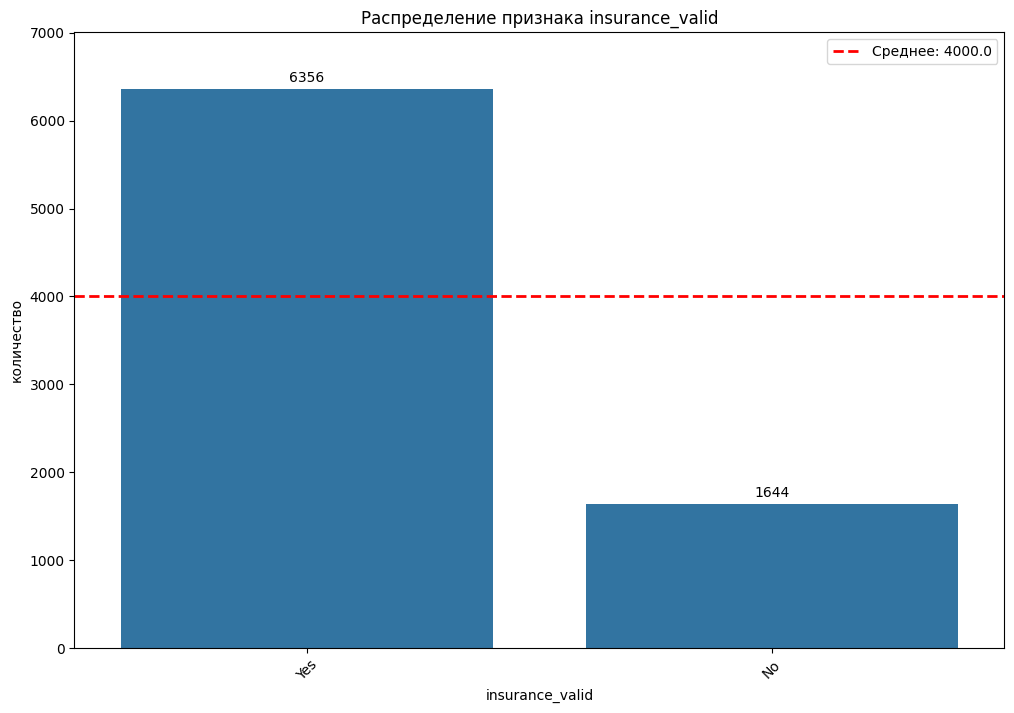

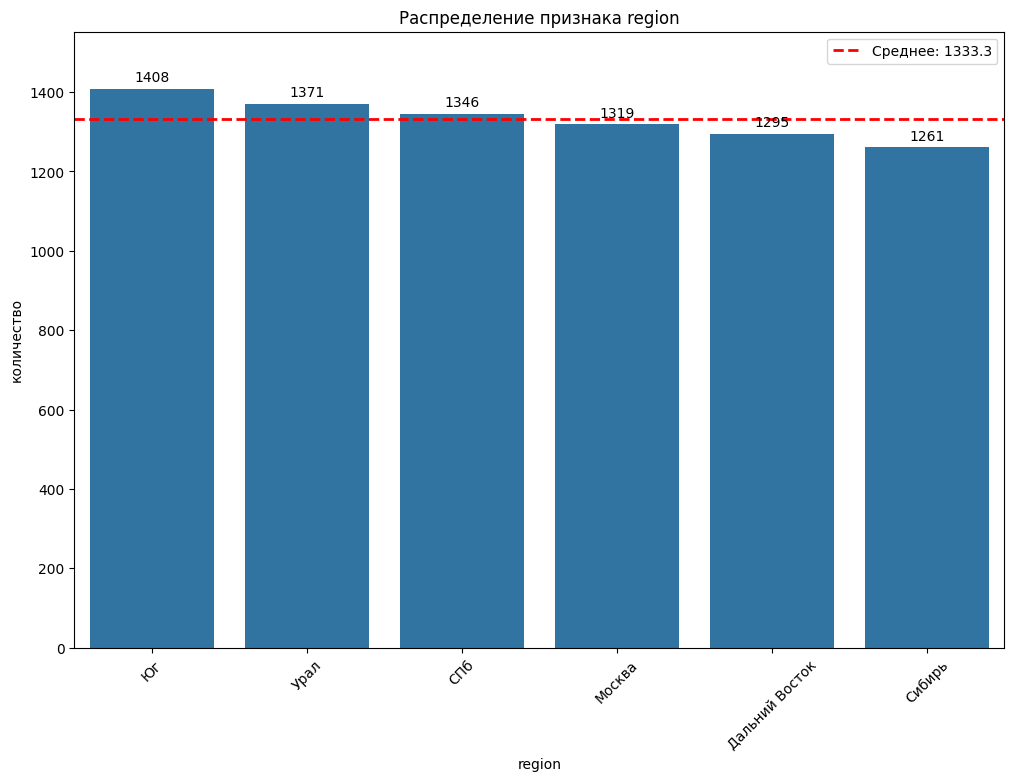

In [20]:
for name in cat_cols_feat:
    plot_count_bars(df=df_train, col_name=name)

Анализ:
- brand	(Марка автомобиля) - в лидерах Nissan, наименне пополярен Ford. По количеству все марки в пределах 10% около среднего.
- region (Макрорегион РФ, в котором продаётся автомобиль) - наиболее популярный ЮГ, наименее - Сибирь. Распределение в в пределах 10% около среднего. 
- color	(Цвет автомобиля) - распределение равномерное (черные и белые чаще встречаются, чем синие и серебрянные, но разница несущественная)
- insurance_valid	(Действительна ли страховка) - существенное преобладание авто с действующей на момент сделки страховки. Разница в 4 раза
- service_history	(Наличие сервисной книжки) - преобладают значения с полной историей, с частичной исторей меньше в ~1.5 раза, без истории меньше в ~2.5 раза
-  transmission	(Тип коробки передач) - механики в 1.5 раза больше, чем автомата
- fuel_type	(Тип топлива) - бензиновые двигателей на 20% больше, чем дизеля. Электрокары малочисленны - более чем в 4 раза меньше, чем остальных видов.

### Корреляционный анализ

In [21]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str]
):
    """Матрица корреляций"""
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=-1,
    )

    return corr_matrix

def plot_corr_matrix(corr_matrix):
    """Тепловая карта"""
    plt.figure(figsize=(14, 10)) 

    sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

    plt.title('Тепловая карта матрицы корреляций')
    plt.show()

def corr_with_target(corr_matrix, target_col_name):
    """Корреляция с таргетом"""
    return corr_matrix[target_col_name].sort_values(ascending=False)

In [22]:
corr_matrix = get_corr_matrix(
    data=df_train, 
    feat_cols=num_cols_feat + cat_cols_feat + [target_col], 
    num_cols=num_cols_feat + [target_col]
)

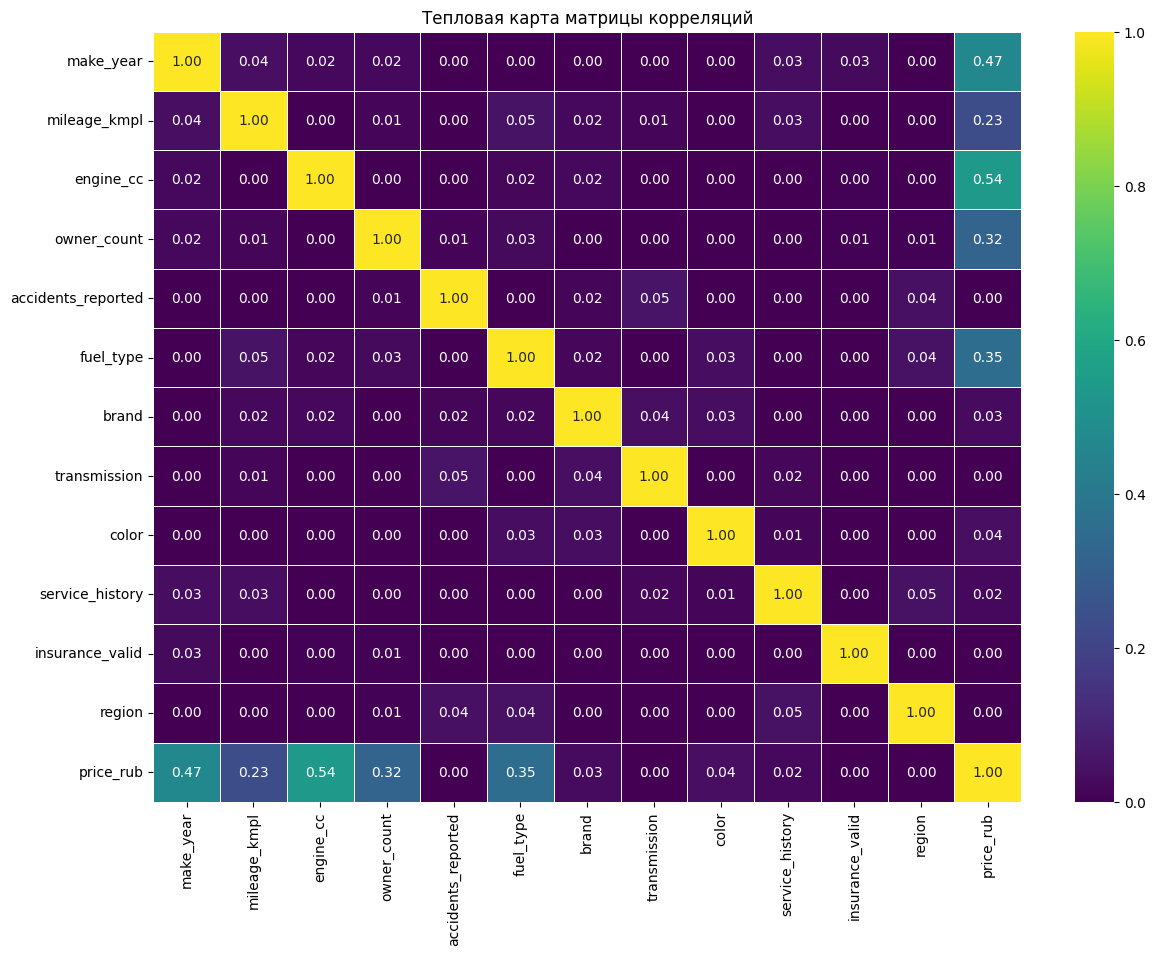

In [23]:
plot_corr_matrix(corr_matrix)

In [24]:
corr_with_target(corr_matrix=corr_matrix, target_col_name=target_col)

price_rub             1.000000
engine_cc             0.539546
make_year             0.466239
fuel_type             0.354523
owner_count           0.316419
mileage_kmpl          0.233398
color                 0.035179
brand                 0.028212
service_history       0.022291
accidents_reported    0.000000
transmission          0.000000
insurance_valid       0.000000
region                0.000000
Name: price_rub, dtype: float64

Анализ:
- наиболее сильная связь таргета с:
    - engine_cc (Объём двигателя) - предположительно, чем больше объем, тем дороже авто
    - make_year (Год выпуска) - предположительно, чем старше машина, тем она дешевле 
    - fuel_type (Тип топлива) - экономичность влияет на стоимость 
    - owner_count (Кол-во владельцев) - предположительно, чем больше было владельцев, тем больше просадка по цене

- По корреляции практически нет связи с:
    - accidents_reported - кол-во ДТП. Это довольно странно, на первый взгляд. Ведь кол-во ДТП должно существенно снижать ценник
    - transmission - коробка передач влияет на комфорт, но, видимо, не на цену
    - insurance_valid - наличие действующей страховки, предположительно, не такой важный фактор при формировании цены
    - region - от региона цена мало зависит 

Замечание:
- как упоминалось в ТЗ, связи могут быть нелинейными и корреляционный анализ может не отражать сложные, скрытые зависимости в данных

### Итог по ИАД

#### Общая информация:
- тренировочный датасет состоит из 8000 объектов
- 7 категориальных и 5 числовых признаков + таргет числовой
- пропусков и дублей нет

#### Распределения:

Таргет:
- распределение таргета симметричное (можно приблизить усеченным слева нормальным распределением)
- в правом хвосте распределения есть малочисленные выбросы 
- на левой границе можно отметить пороговое значение 95000 (подозрительно ровная сумма!), ниже которого значений нет. Возможно, это фиксированная нижняя цена для всех покупаемых на перепродажу авто. 

Количественные признаки:
- make_year	(Год выпуска) - распределение равномерное.
- mileage_kmpl	(Пробег (км)) - симметричное распределение с явной минимальной границей в 5.0км. Есть малочисленные экстремальные значения на правом хвосте
- engine_cc	(Объём двигателя (в кубических см)) - дискретный набор стандартных по объему двигателя значений. Среди дискретных значений распределение равномерное. Чаще встречаются двигателя объемом до 2000 куб. см.
- owner_count	(Количество владельцев по ПТС) - от 1 до 5 целые значения. Распределение равномерное
- accidents_reported	(Количество зафиксированных ДТП) - от 0 до 5 целые значения. Распределение экспоненциально убывает. Чтобы усилить связь большого кол-ва ДТП с целевую переменной, стоит рассмотреть преобразование возведения в степень.


Категориальные:
- brand	(Марка автомобиля) - в лидерах Nissan, наименне пополярен Ford. По количеству все марки в пределах 10% около среднего.
- region (Макрорегион РФ, в котором продаётся автомобиль) - наиболее популярный ЮГ, наименее - Сибирь. Распределение в в пределах 10% около среднего. 
- color	(Цвет автомобиля) - распределение равномерное (черные и белые чаще встречаются, чем синие и серебрянные, но разница несущественная)
- insurance_valid	(Действительна ли страховка) - существенное преобладание авто с действующей на момент сделки страховки. Разница в 4 раза
- service_history	(Наличие сервисной книжки) - преобладают значения с полной историей, с частичной исторей меньше в ~1.5 раза, без истории меньше в ~2.5 раза
-  transmission	(Тип коробки передач) - механики в 1.5 раза больше, чем автомата
- fuel_type	(Тип топлива) - бензиновые двигателей на 20% больше, чем дизеля. Электрокары малочисленны - более чем в 4 раза меньше, чем остальных видов.

#### Корреляционный анализ:

- наиболее сильная связь таргета с:
    - engine_cc (Объём двигателя) - предположительно, чем больше объем, тем дороже авто
    - make_year (Год выпуска) - предположительно, чем старше машина, тем она дешевле 
    - fuel_type (Тип топлива) - экономичность влияет на стоимость 
    - owner_count (Кол-во владельцев) - предположительно, чем больше было владельцев, тем больше просадка по цене

- По корреляции практически нет связи с:
    - accidents_reported - кол-во ДТП. Это довольно странно, на первый взгляд. Ведь кол-во ДТП должно существенно снижать ценник
    - transmission - коробка передач влияет на комфорт, но, предположительно, не на цену
    - insurance_valid - наличие действующей страховки, предположительно, не такой важный фактор при формировании цены
    - region - от региона цена, предположительно, мало зависит 

Замечание:
- связи могут быть нелинейными и корреляционный анализ может не отражать сложные, скрытые зависимости в данных


#### Выводы
- для количественных данных с симметричными распределениями можно рассмотреть фильтрацию экстремальных внутри пайплайна предобработки данных
- для дискретных данных, которые показали низкую корреляцию с таргетом можно попробовать применить преобразование признаков: возведение в степень для accidents_reported, например 

---
## 3. Предобработка

- Подготовьте признаки.
- Сформируйте одинаковые обучающие и валидационные выборки для всех трёх библиотек.
- Используйте файл ds_s16_test_data.csv как отложенную тестовую выборку.

In [ ]:
for col in cat_cols_feat:
	# приведение всех категориальных признаков к pd.categorical
	df_train[col] = df_train[col].astype('category')

#### Разделение на выборки

In [26]:
X_train_val = df_train.drop(columns='price_rub')
y_train_val = pd.Series(df_train['price_rub'], name='target')
display(X_train_val.head(), y_train_val)

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,Сибирь


0       242073
1       426029
2       727050
3       753168
4       733390
         ...  
7995    993550
7996    487962
7997    808630
7998    642222
7999    622646
Name: target, Length: 8000, dtype: int64

In [27]:
# train 80% и validate 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    shuffle=True,
    random_state=RANDOM_SEED
)

In [28]:
X_train.shape, X_val.shape

((6400, 12), (1600, 12))

---
## 4. Обучение моделей в разных библиотеках

In [29]:
def get_overpricing_rate(y_true, y_pred):
    # Рассчитываем относительное отклонение
    error_ratio = (y_pred - y_true) / y_true
    # Считаем долю тех, где отклонение выше 20%
    overpricing_rate = (error_ratio > 0.20).mean()

    return overpricing_rate


def get_underpricing_loss(y_true, y_pred):
    error_ratio = (y_pred - y_true) / y_true
    # Находим маску (фильтр) для случаев занижения цены на 20%+
    under_mask = error_ratio < -0.20
    # Суммируем разницу между реальной ценой и предсказанием для этих случаев
    underpricing_loss = (y_true[under_mask] - y_pred[under_mask]).sum()
    return underpricing_loss

def calc_metrics(y_pred, y_true, model_name: str):
    # 1
    overpricing_rate = get_overpricing_rate(y_true, y_pred)

    # 2
    underpricing_loss = get_underpricing_loss(y_true, y_pred)

    # 3
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    result_df = pd.DataFrame(
        {   'model_name': model_name,
            'overpricing_rate': overpricing_rate,
            'underpricing_loss': underpricing_loss,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }, index=[0]
    )
    return result_df

### Обучение базовой модели XGBoost

In [30]:
def plot_xgb_model_learning_curve(xgb_model):
    # Достаём значения метрики rmse на каждой итерации обучения
    results = xgb_model.evals_result()

    epochs = len(results['validation_0']['mae'])
    x = range(epochs)

    # Строим график
    plt.plot(x, results['validation_0']['mae'], label='MAE на обучающей выборке')
    plt.plot(x, results['validation_1']['mae'], label='MAE на валидационной выборке')
    plt.xlabel('Кол-во итераций (n_estimators)')
    plt.ylabel('Значение MAE')
    plt.title('График зависимости значения MAE на обучающей/валидационной выборках')
    plt.legend()
    plt.grid(True)
    plt.show()

In [31]:
xgb_model_base = XGBRegressor(
    objective='reg:absoluteerror',  # минимизация MAE на train
    random_state=RANDOM_SEED, 
    enable_categorical=True,
    learning_rate=0.3,
    eval_metric="mae", # оценка MAE на validate
    n_estimators=100,
    n_jobs=-1,
    early_stopping_rounds=20
)

In [32]:
# Обучаем модель с eval_set
xgb_model_base.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=20,
             enable_categorical=True, eval_metric='mae', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.3, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, objective='reg:absoluteerror', ...)

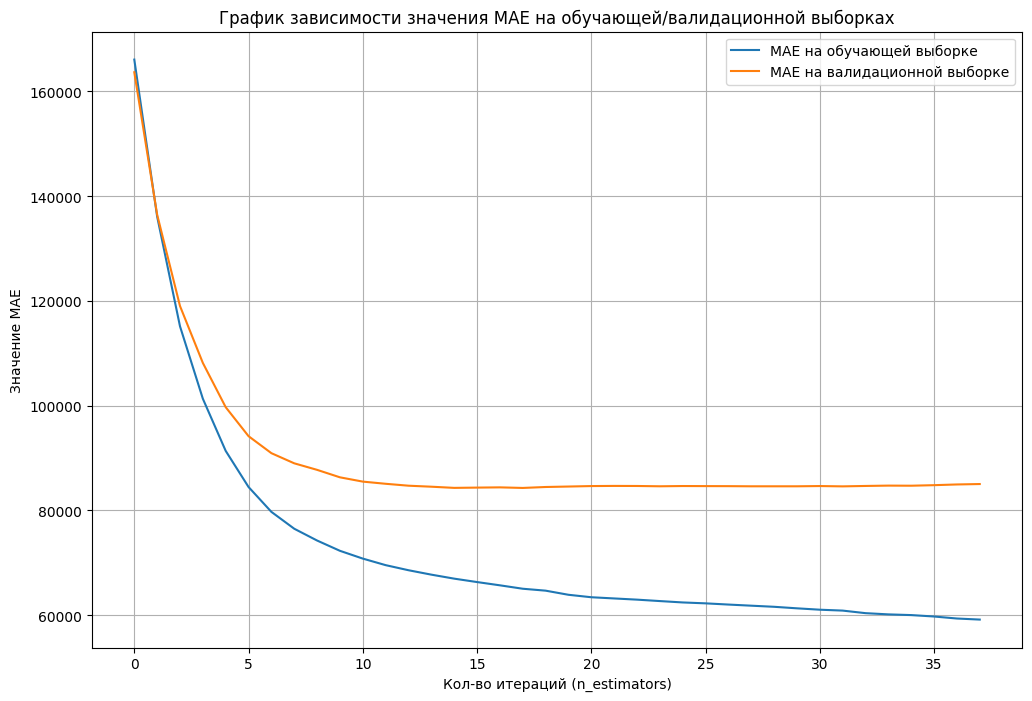

In [33]:
plot_xgb_model_learning_curve(xgb_model_base)

Анализ:
- без ранней остановки бустинг существенно переобучается: на validate ошибка перестает падать после 10ой итерации

In [34]:
# метрики на validate
y_val_pred_xgb_model_base = xgb_model_base.predict(X_val)
xgb_model_base_metrics = calc_metrics(
    y_pred=y_val_pred_xgb_model_base, y_true=y_val, model_name='xgb_model_base'
)
xgb_model_base_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,xgb_model_base,0.146875,2.228710e+07,106645.9375,84286.460938,0.832067


### Обучение базовой модели LightGBM

In [35]:
lgbm_base = LGBMRegressor(
    objective='regression_l1', # MAE функция потерь
    metric='mae', # оценка по MAE на валиадции 
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

In [36]:
lgbm_base.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols_feat, 
    eval_metric='mae',
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 347
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 12
[LightGBM] [Info] Start training from score 662700.500000


LGBMRegressor(metric='mae', n_jobs=-1, objective='regression_l1',
              random_state=42)

In [37]:
# предсказания на validate
y_pred_val_lgbm_base = lgbm_base.predict(X_val)

In [38]:
lgbm_base_metrics = calc_metrics(
    y_pred=y_pred_val_lgbm_base, y_true=y_val, model_name='lgbm_base'
)
lgbm_base_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,lgbm_base,0.139375,1.955611e+07,102803.932005,81979.305408,0.843949


### Обучение базовой модели CatBoost

In [39]:
# Инициализируем CatBoostRegressor
cbr_model_base = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    random_state=RANDOM_SEED, 
    n_estimators=500,               
    l2_leaf_reg=1.0,               # регуляризация
    early_stopping_rounds=50,     # остановка при отсутствии улучшения
    use_best_model=True,           # сохранить лучшую модель
)

In [40]:
cbr_model_base.fit(
    X_train,
    y_train,
    cat_features=cat_cols_feat,
    eval_set=(X_val, y_val),
    verbose=200,
    use_best_model=True
)

0:	learn: 208483.8811081	test: 202214.2293712	best: 202214.2293712 (0)	total: 58.9ms	remaining: 29.4s
200:	learn: 73667.6616613	test: 79815.2632950	best: 79815.2632950 (200)	total: 481ms	remaining: 715ms
400:	learn: 71181.0602919	test: 79412.0710348	best: 79401.2998240 (373)	total: 888ms	remaining: 219ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 79401.29982
bestIteration = 373

Shrink model to first 374 iterations.


CatBoostRegressor(early_stopping_rounds=50, eval_metric='MAE', l2_leaf_reg=1.0, loss_function='MAE', n_estimators=500, random_state=42, use_best_model=True)

In [41]:
# предсказания на validate
y_pred_val_cbr_model_base = cbr_model_base.predict(X_val)

In [42]:
cbr_base_metrics = calc_metrics(
    y_pred=y_pred_val_cbr_model_base, y_true=y_val, model_name='cbr_model_base'
)
cbr_base_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,cbr_model_base,0.134375,1.635428e+07,99008.868158,79401.299825,0.855258


### Сравнительная таблица

In [43]:
results = pd.concat(
    [cbr_base_metrics, lgbm_base_metrics, xgb_model_base_metrics],
).sort_values(by='mae')
results

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,cbr_model_base,0.134375,1.635428e+07,99008.868158,79401.299825,0.855258
0,lgbm_base,0.139375,1.955611e+07,102803.932005,81979.305408,0.843949
0,xgb_model_base,0.146875,2.228710e+07,106645.937500,84286.460938,0.832067


Анализ:
- по всем метрикам CatBoostRegressor лидирует:
    - overpricing_rate: +1% LGBMRegressor, +10% XGBRegressor
    - underpricing_loss: +20% LGBMRegressor, +50% XGBRegressor
    - rmse,	mae: у CatBoostRegressor меньше на 5-7%
    - r2: у CatBoostRegressor больше на 2-3%

---
## 5. Работа с параметрами модели (Тюнинг)


### Подбор гиперпараметров для XGBRegressor

In [44]:
def objective_xgb(trial):
    """
    Функция-цель для оптимизации параметров xgb
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0),
        "objective": 'reg:absoluteerror',
        "random_state": RANDOM_SEED, 
        "enable_categorical": True,
        "eval_metric": "mae", 
        "n_jobs": -1, 
        "early_stopping_rounds": 30
    }

    model = XGBRegressor(
        **params, 
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )
    y_val_pred = model.predict(X_val)

    score = mean_absolute_error(y_val, y_val_pred)

    return score

In [ ]:
# исследование
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

In [46]:
# запуск оптимизации
study_xgb = optuna.create_study(direction="minimize", sampler=sampler) 
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True) 

[I 2026-06-24 00:36:16,730] A new study created in memory with name: no-name-2819b713-04d8-4803-8af4-61288ed04970


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-24 00:36:18,039] Trial 0 finished with value: 84282.0390625 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'gamma': 0.5986584882104518, 'reg_lambda': 1.5601864128641787, 'reg_alpha': 1.5599452118020811}. Best is trial 0 with value: 84282.0390625.
[I 2026-06-24 00:36:19,885] Trial 1 finished with value: 83340.0625 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 9, 'n_estimators': 1402, 'gamma': 0.7080725807153196, 'reg_lambda': 0.2058449527521795, 'reg_alpha': 9.699098521920844}. Best is trial 1 with value: 83340.0625.
[I 2026-06-24 00:36:20,318] Trial 2 finished with value: 80928.28125 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'gamma': 0.1834045180193887, 'reg_lambda': 3.0424224365529544, 'reg_alpha': 5.2475643210748135}. Best is trial 2 with value: 80928.28125.
[I 2026-06-24 00:36:21,306] Trial 3 finished with value: 81457.4375 and parameters: {'learning_ra

In [47]:
xgb_best_opt = XGBRegressor(
    **study_xgb.best_params, 
    enable_categorical=True,
    objective='reg:absoluteerror',
    random_state=RANDOM_SEED,
    eval_metric="mae", 
    n_jobs=-1, 
    early_stopping_rounds=30
)

In [48]:
xgb_best_opt.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
y_val_pred_xgb_best_opt = xgb_best_opt.predict(X_val)
xgb_best_opt_metrics = calc_metrics(
    y_true=y_val, y_pred=y_val_pred_xgb_best_opt, model_name='xgb_best_opt'
)
xgb_best_opt_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,xgb_best_opt,0.13375,1.966904e+07,100714.851562,80148.0,0.850227


### Подбор гиперпараметров для LGBMRegressor

In [49]:
def objective_lgbm(trial):
    """
    Функция-цель для оптимизации параметров lgbm
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "num_leaves": trial.suggest_int("num_leaves", 20, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "random_state": RANDOM_SEED, 
        "enable_categorical": True,
        "objective": 'regression_l1', # MAE функция потерь
        "metric":'mae', # оценка по MAE на валиадции 
        "n_jobs": -1, 
        "early_stopping_rounds": 30,
        "verbose": -1,
    }

    model = LGBMRegressor(
        **params, 
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_metric="mae", 
    )
    y_val_pred = model.predict(X_val)

    score = mean_absolute_error(y_val, y_val_pred)

    return score

In [50]:
# запуск оптимизации
study_lgbm = optuna.create_study(direction="minimize", sampler=sampler) 
study_lgbm.optimize(objective_lgbm, n_trials=30, show_progress_bar=True) 

[I 2026-06-24 00:36:41,020] A new study created in memory with name: no-name-073f172e-0a3d-4e19-b31c-f0244fbbe95d


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-24 00:36:42,779] Trial 0 finished with value: 81431.3760627522 and parameters: {'learning_rate': 0.02447244097399012, 'max_depth': 5, 'n_estimators': 1743, 'num_leaves': 104, 'min_child_samples': 31, 'reg_lambda': 0.0002195678075127562, 'reg_alpha': 1.3408920002835402e-07}. Best is trial 0 with value: 81431.3760627522.
[I 2026-06-24 00:36:43,135] Trial 1 finished with value: 80707.56134882418 and parameters: {'learning_rate': 0.06341572775495277, 'max_depth': 3, 'n_estimators': 1981, 'num_leaves': 203, 'min_child_samples': 24, 'reg_lambda': 1.1070747281639212e-08, 'reg_alpha': 0.03339576740674936}. Best is trial 1 with value: 80707.56134882418.
[I 2026-06-24 00:36:44,610] Trial 2 finished with value: 81792.35554359926 and parameters: {'learning_rate': 0.050916359458185526, 'max_depth': 8, 'n_estimators': 1657, 'num_leaves': 37, 'min_child_samples': 39, 'reg_lambda': 8.451863533931625e-08, 'reg_alpha': 0.08032068562667226}. Best is trial 1 with value: 80707.56134882418.
[I 20

In [51]:
lgbm_best_opt = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=RANDOM_SEED, 
    enable_categorical=True,
    objective='regression_l1', # MAE функция потерь
    metric='mae', # оценка по MAE на валиадции 
    n_jobs=-1, 
    early_stopping_rounds=30,
    verbose=-1,
)

In [52]:
lgbm_best_opt.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
)
y_val_pred_lgbm_best_opt = lgbm_best_opt.predict(X_val)
lgbm_best_opt_metrics = calc_metrics(
    y_pred=y_val_pred_lgbm_best_opt, y_true=y_val, model_name='lgbm_best_opt'
)
lgbm_best_opt_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,lgbm_best_opt,0.135,1.878680e+07,100765.550596,80167.245165,0.850076


### Подбор гиперпараметров для CatBoost

In [53]:
def objective_catboost(trial):
    """
    Функция-цель для оптимизации параметров catboost
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1., 10.),
    }

    model = CatBoostRegressor(
        **params, 
        random_state=RANDOM_SEED, 
        loss_function="MAE", 
        eval_metric="MAE",
        early_stopping_rounds=200,
        use_best_model=True,   
        verbose=False,
    )


    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols_feat,
    )
    y_val_pred = model.predict(X_val)

    score = mean_absolute_error(y_val, y_val_pred)

    return score

In [54]:
# запуск оптимизации
study_catboost = optuna.create_study(direction="minimize", sampler=sampler) 
study_catboost.optimize(objective_catboost, n_trials=30, show_progress_bar=True) 

[I 2026-06-24 00:37:19,201] A new study created in memory with name: no-name-f40efd13-8521-4a21-823e-36a4fc788484


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-24 00:37:20,118] Trial 0 finished with value: 79305.2745510098 and parameters: {'learning_rate': 0.06836314065022722, 'max_depth': 4, 'n_estimators': 679, 'l2_leaf_reg': 4.038536542632651}. Best is trial 0 with value: 79305.2745510098.
[I 2026-06-24 00:37:20,503] Trial 1 finished with value: 81756.47688671888 and parameters: {'learning_rate': 0.7688106801474951, 'max_depth': 5, 'n_estimators': 1278, 'l2_leaf_reg': 7.3271706300566}. Best is trial 0 with value: 79305.2745510098.
[I 2026-06-24 00:37:23,605] Trial 2 finished with value: 80354.0952586017 and parameters: {'learning_rate': 0.0533653306637961, 'max_depth': 10, 'n_estimators': 1944, 'l2_leaf_reg': 3.2660406624282774}. Best is trial 0 with value: 79305.2745510098.
[I 2026-06-24 00:37:24,328] Trial 3 finished with value: 79608.88466091918 and parameters: {'learning_rate': 0.09874088417386245, 'max_depth': 5, 'n_estimators': 927, 'l2_leaf_reg': 1.3319825261907952}. Best is trial 0 with value: 79305.2745510098.
[I 2026-0

In [55]:
catboost_best_opt = CatBoostRegressor(
    **study_catboost.best_params, 
    random_state=RANDOM_SEED, 
    loss_function="MAE", 
    eval_metric="MAE",
    early_stopping_rounds=200,
    use_best_model=True,   
    verbose=False,
)

In [56]:
catboost_best_opt.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_cols_feat,
)
y_val_pred_catboost_best_opt = catboost_best_opt.predict(X_val)
catboost_best_opt_metrics = calc_metrics(
    y_pred=y_val_pred_catboost_best_opt, y_true=y_val, model_name='catboost_best_opt'
)
catboost_best_opt_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,catboost_best_opt,0.134375,1.651965e+07,98801.336905,79268.290293,0.855864


### Сравнительная таблица

In [57]:
results = pd.concat(
    [results, xgb_best_opt_metrics, lgbm_best_opt_metrics, catboost_best_opt_metrics]
).sort_values(by='mae')
results

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,catboost_best_opt,0.134375,1.651965e+07,98801.336905,79268.290293,0.855864
0,cbr_model_base,0.134375,1.635428e+07,99008.868158,79401.299825,0.855258
0,xgb_best_opt,0.133750,1.966904e+07,100714.851562,80148.000000,0.850227
0,lgbm_best_opt,0.135000,1.878680e+07,100765.550596,80167.245165,0.850076
0,lgbm_base,0.139375,1.955611e+07,102803.932005,81979.305408,0.843949
0,xgb_model_base,0.146875,2.228710e+07,106645.937500,84286.460938,0.832067


Анализ:
- оптимизация гиперпараметров позволила улучшить метрики для каждой модели
- лучшая модель по ключевому показателю MAE: catboost_best_opt - оптимизированный **CatBoostRegressor**. В ходе оптимизации удалось добиться несущественных улучшений по mae, overpricing_rate, rmse, r2 (менее 1% улучшение). По underpricing_loss ухудшение (рост показателя) на 4%.

Итог:
- для дальнейшего анализа и финальной проверки принято решение использовать модель **CatBoostRegressor** с оптимизированными параметрами, поскольку по большинству важных для бизнеса метрик эта модель показывает лучшие результаты


---
## 6. Интерпретация и бизнес-анализ


In [58]:
# топ 3 модели (при наличии неоптимизированной модели такого же типа она исключается из топа)
best_models = [
    (catboost_best_opt, 'catboost_best_opt'),
    (xgb_best_opt, 'xgb_best_opt'),
    (lgbm_best_opt, 'lgbm_best_opt') 
]

In [59]:
def show_shap_analysis(model, name, X_val):
    # Создаём explainer и вычисляем SHAP-значения
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_val, plot_type="dot", show=False)
    axes[0].set_title(
        f"Распределение влияния признаков для {name}", fontsize=14, pad=15
    )

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
    axes[1].set_title(
        f"Глобальная важность (средний |SHAP|) для {name}",
        fontsize=14,
        pad=15,
    )

    # 4. Выравниваем отступы и показываем
    plt.tight_layout()
    plt.show()


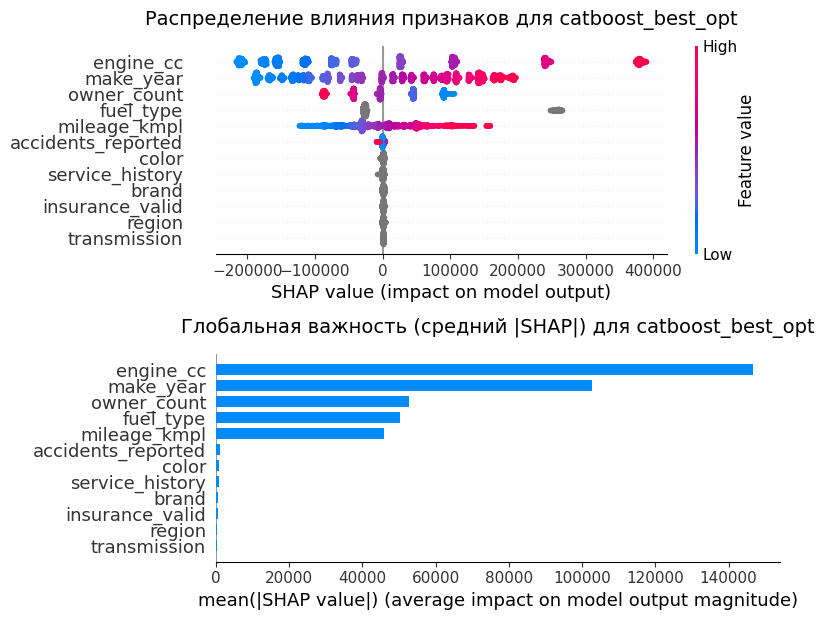

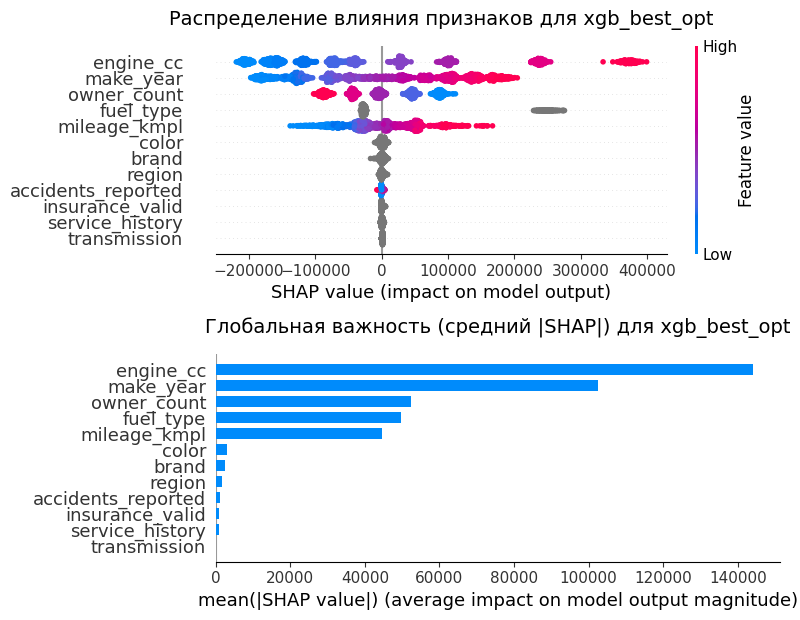

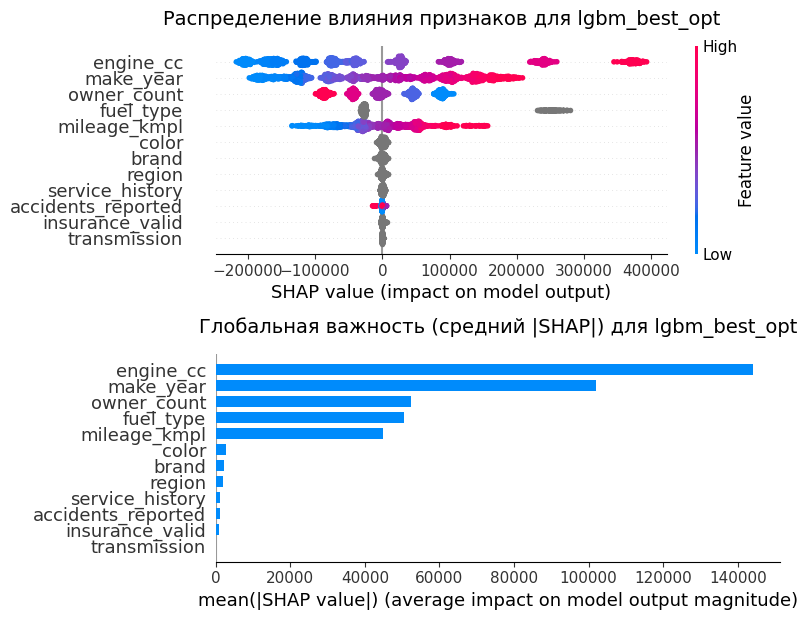

In [60]:
for model, name in best_models:
    show_shap_analysis(model, name, X_val)

Анализ:
- лучшие модели показывают схожие результаты по важности признаков:
- в топе по важности находятся:
    - engine_cc - наиболее важный признак. Прослеживается прямая зависимость: чем выше объем двигателя, тем выше цена авто
    - make_year - чем новее авто, тем оно дороже
    - owner_count - обратная зависимость: чем больше владельцев, тем дешевле авто
    - fuel_type - значимый признак для предсказаний всех моделей. Какой именно характер связи с таргетом по приведенному графику нельзя сказать
    - mileage_kmpl - важный признак с положительной связью с ценой на авто: чем экономичней авто, тем оно более востребовано и, как следствие, оно дороже.
- остальные признаки существенно уступают по значимости


### Сравнение по бизнес-рискам

In [61]:
results[['model_name', 'overpricing_rate', 'underpricing_loss']]

,model_name,overpricing_rate,underpricing_loss
0,catboost_best_opt,0.134375,1.651965e+07
0,cbr_model_base,0.134375,1.635428e+07
0,xgb_best_opt,0.133750,1.966904e+07
0,lgbm_best_opt,0.135000,1.878680e+07
0,lgbm_base,0.139375,1.955611e+07
0,xgb_model_base,0.146875,2.228710e+07


Анализ:
- catboost_best_opt и cbr_model_base лучшие с точки зрения бизнес-рисков: самые низкие показатели overpricing_rate и underpricing_loss среди других моделей. 
- различие по риск-метрикам между catboost_best_opt и cbr_model_base несущесвтвенное и составляет 2-4%. 

Итог:
- по бизнес рискам можно рекомендовать к использованию оптимизированную и базовую модель CatBoost

### Склонность к завышению и занижению по маркам

In [62]:
def metrics_analysis(y_val_pred, y_val, X_val, metric_func, metric_name: str, groupby_feature: str):

    y_val_pred_series = pd.Series(data=y_val_pred, name='target')
    brand_analysis = pd.concat([y_val_pred_series, X_val[groupby_feature].reset_index(drop=True)], ignore_index=True, axis=1)
    brand_analysis.columns = ['target', groupby_feature]
    
    # Расчет метрики
    brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))
    brand_analysis_overpricing_rate = brand_analysis_overpricing_rate.sort_values()
    
    # Строим график
    ax = brand_analysis_overpricing_rate.plot.barh(color='royalblue', edgecolor='black')

    # Добавляем значения на столбцы
    for index, value in enumerate(brand_analysis_overpricing_rate):
        # Округляем значение до 3 знаков (настройте под себя, например, {:.1%} для процентов)
        label = f"{value:.3f}" 
        
        # Размещаем текст чуть правее самого столбца
        ax.text(
            x=value + (max(brand_analysis_overpricing_rate) * 0.01), 
            y=index,                                                 
            s=label,                                                 
            va='center',                                             
            ha='left',                                              
            fontsize=9                                              
        )

    # Настройка границ, чтобы текст справа не обрезался
    plt.xlim(0, max(brand_analysis_overpricing_rate) * 1.15)
    
    plt.title(f'{metric_name} по {groupby_feature}')
    plt.xlabel(f'{metric_name}')
    plt.tight_layout()
    plt.show()

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_39691/479580336.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))


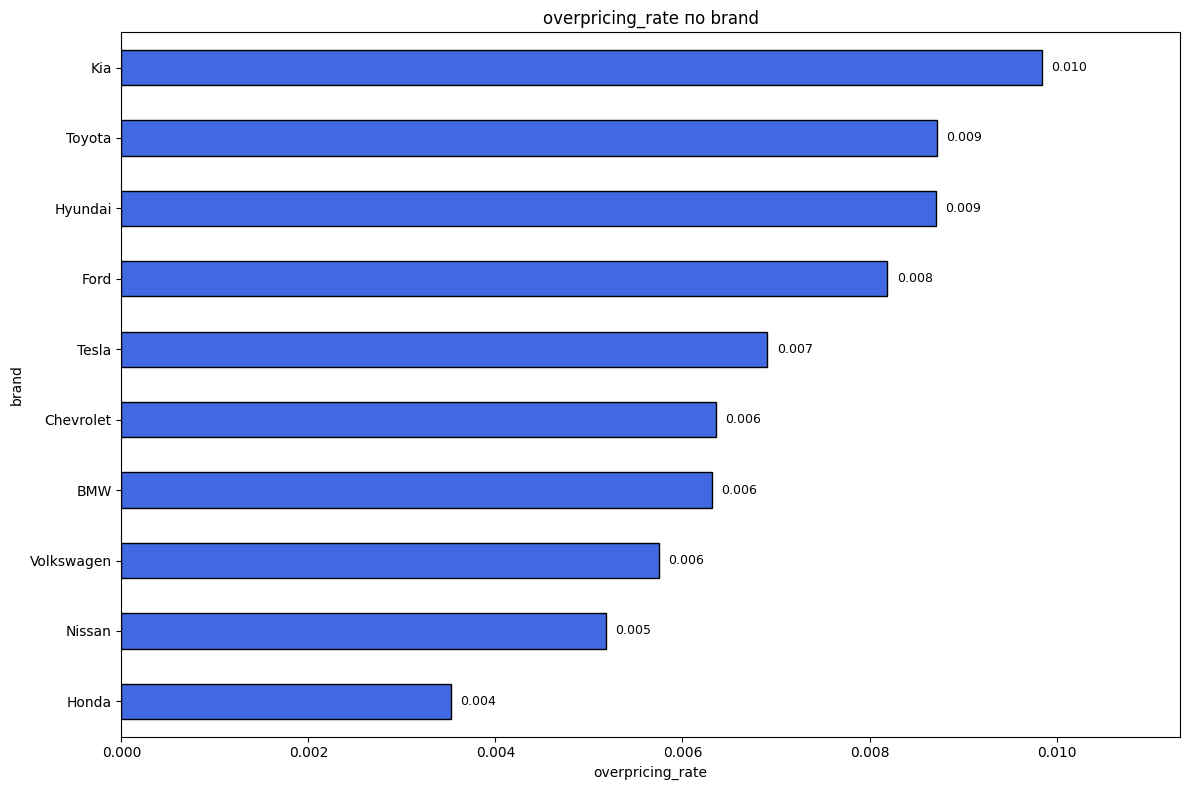

In [63]:
metrics_analysis(
    y_val_pred=y_val_pred_catboost_best_opt, y_val=y_val, X_val=X_val, 
    metric_func=get_overpricing_rate, metric_name='overpricing_rate',
    groupby_feature='brand'
)

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_39691/479580336.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))


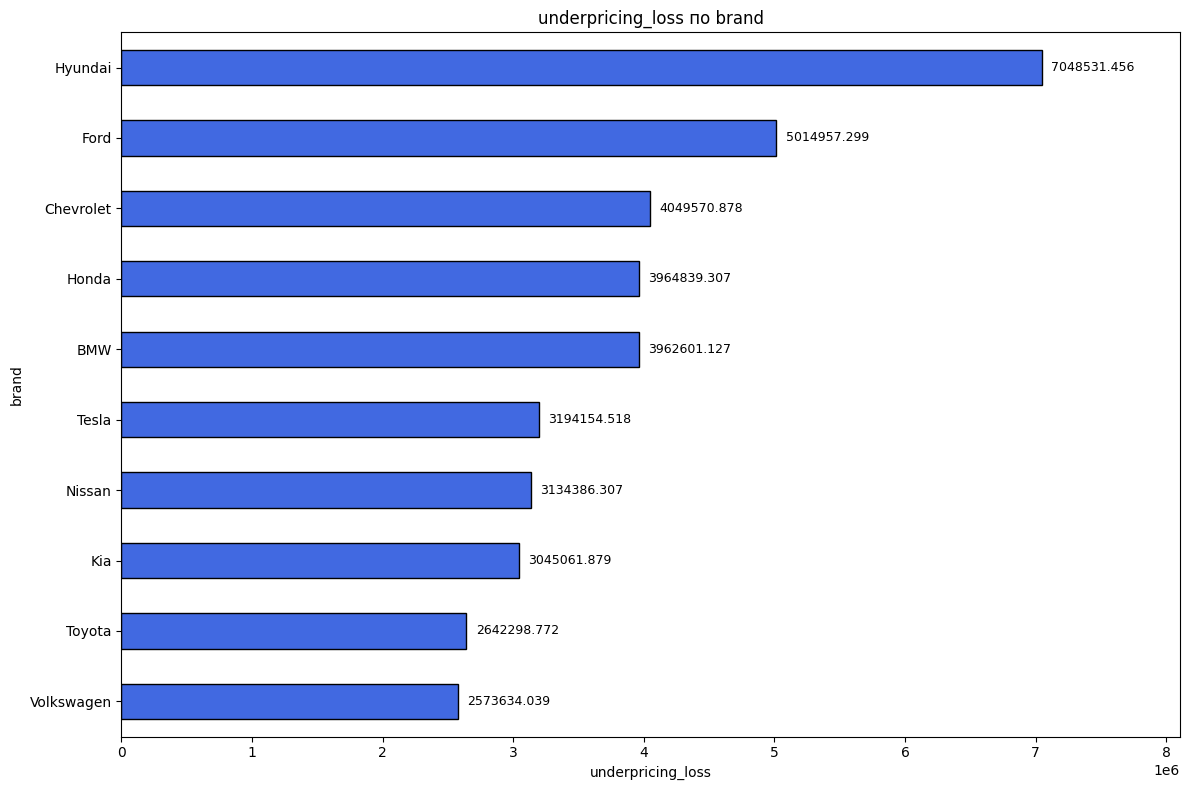

In [64]:
metrics_analysis(
    y_val_pred=y_val_pred_catboost_best_opt, y_val=y_val, X_val=X_val, 
    metric_func=get_underpricing_loss, metric_name='underpricing_loss',
    groupby_feature='brand'
)

Анализ:
- модель систематически завышает цену для марок KIA, Toyota, Hyundai - наиболее высокие показатели по матрике overpricing_rate
- наиболее высокие потери от недооценки у мароки Hyandai - на 50% и более выше потери от недооценки этого бренда (наболее высокие показатели по метрике underpricing_loss)

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_39691/479580336.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))


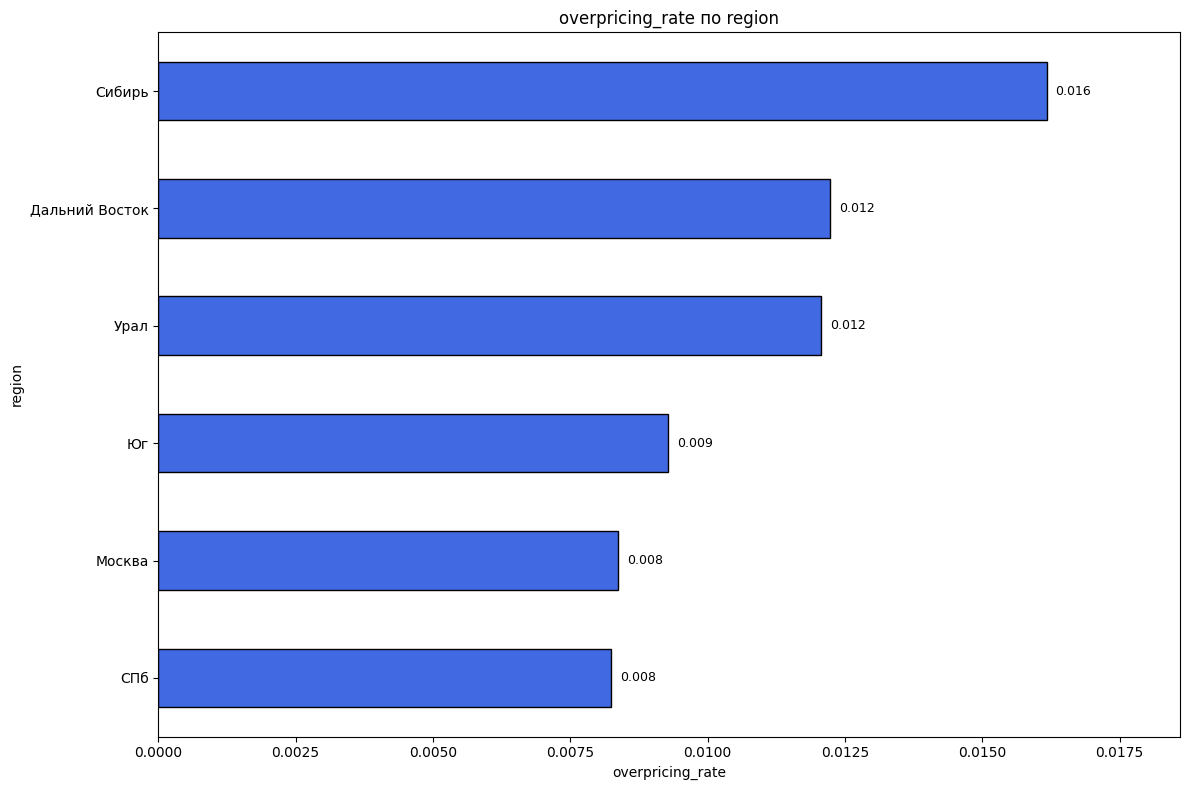

In [65]:
metrics_analysis(
    y_val_pred=y_val_pred_catboost_best_opt, y_val=y_val, X_val=X_val, 
    metric_func=get_overpricing_rate, metric_name='overpricing_rate',
    groupby_feature='region'
)

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_39691/479580336.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))


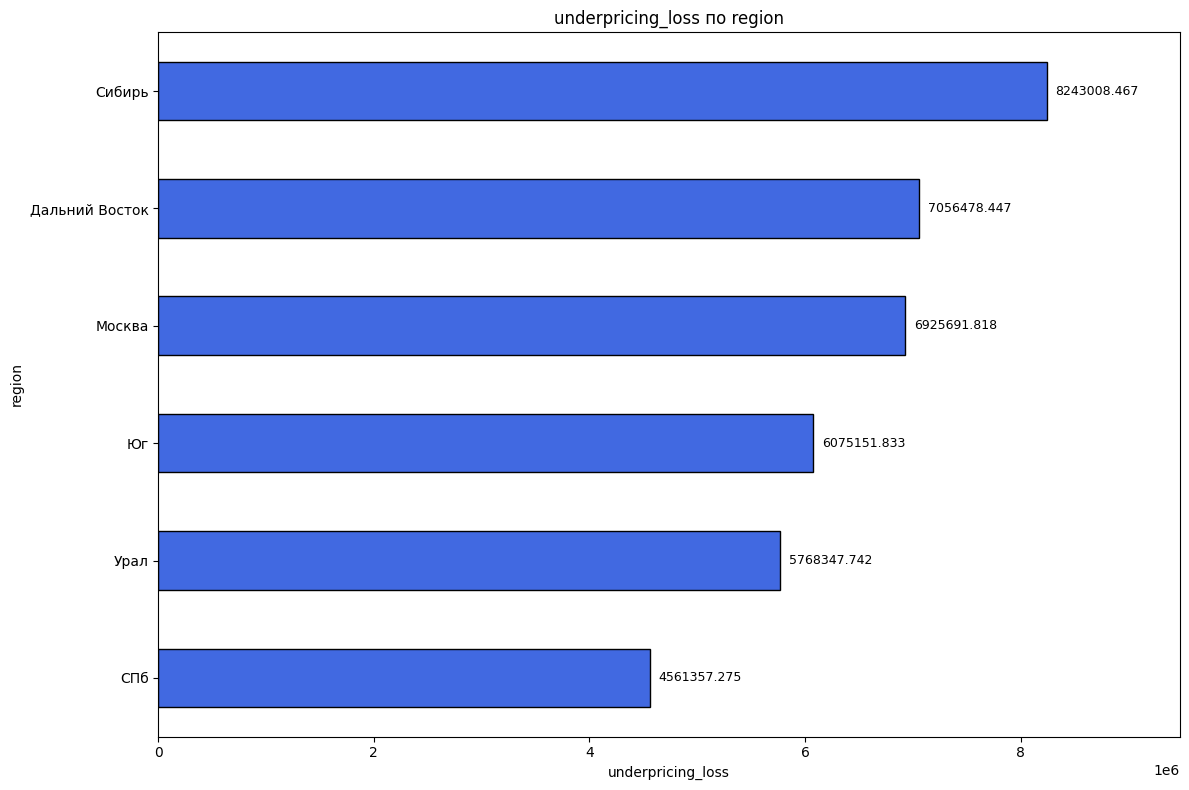

In [66]:
metrics_analysis(
    y_val_pred=y_val_pred_catboost_best_opt, y_val=y_val, X_val=X_val, 
    metric_func=get_underpricing_loss, metric_name='underpricing_loss',
    groupby_feature='region'
)

Анализ:
- модель систематически завышает цену для регионов Сибирь - наиболее высокие показатели по матрике overpricing_rate
- наиболее высокие потери от недооценки у регионов: Сибирь - наболее высокие показатели по метрике underpricing_loss 

---
## 7. Финальная проверка

In [67]:
for col in cat_cols_feat:
	# приведение всех категориальных признаков к pd.categorical
	df_test[col] = df_test[col].astype('category')

In [68]:
X_test = df_test.drop(columns='price_rub')
y_test = pd.Series(df_test['price_rub'], name='target')

In [69]:
y_test_pred = catboost_best_opt.predict(X_test)
y_val_pred = catboost_best_opt.predict(X_val)

In [71]:
results_test = calc_metrics(y_true=y_test, y_pred=y_test_pred, model_name='catboost_best_opt на test')
results_val = calc_metrics(y_true=y_val, y_pred=y_val_pred, model_name='catboost_best_opt на val')

pd.concat([results_val, results_test])

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,catboost_best_opt на val,0.134375,1.651965e+07,98801.336905,79268.290293,0.855864
0,catboost_best_opt на test,0.131500,1.938657e+07,94603.780387,75543.611236,0.875347


Анализ:

Модель показывает стабильные результаты по ключевым метрикам на validate и test
- наблюдается несущественное улучшение по метрикам rmse: -4%, mae: -5%, r2: +2%, overpricing_rate: -2%
- по метрике underpricing_loss на test ухудшение на 17%
- модель не переобучилась - большая часть метрик стабильна на новых данных. Больше всего варьируется показатель потерь от недооценки underpricing_loss.

Итог:

- Разработанная модель обладает высокой обощающей способностью, но имеет склонность к недооценке авто на новых данных.

---
## 8. Описание выводов и финальный вердикт

Общая информация:
- Проведен сравнительный анализ оптимизированных по гиперпараметрам моделей градиентного бустинга. 
- В сравнении участовали модели из библиотек XGBoost, CatBoost и LightGBM.
- По результатам сравнения была выявлена по ключевой бизнес метрике лучшая модель:  CatBoost с оптимизированными гиперпараметрами.

Наиболее важными при оценке авто признаками яляются:  
- engine_cc - наиболее важный признак. Прослеживается прямая зависимость: чем выше объем двигателя, тем выше цена авто
- make_year - чем новее авто, тем оно дороже
- owner_count - обратная зависимость: чем больше владельцев, тем дешевле авто
- fuel_type - значимый признак для предсказаний всех моделей
- mileage_kmpl - важный признак с положительной связью с ценой на авто: чем меньше расход, тем выше стоимость 

Финальная проверка:
- модель показывает стабильное качество на новых данных по большинству показателей, но имеет склонность к недооценке авто
- модель проверена на отложенной выборке и рекомендована к внедерению 
- метрики на финальной проверке: mae = 75543, overpricing_rate=0.132, underpricing_loss=1.938657e+07